# 01 — Exploratory Data Analysis (EDA)
## EMSCAD Dataset — Employment Scam Aegean Dataset

This notebook explores the dataset to understand:
- Shape and structure (17,880 rows, 18 columns)
- Class distribution (real vs fake — heavy imbalance)
- Missing values patterns
- Industry/sector patterns in fake posts
- Key feature correlations
- Word frequency analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('../datasets/raw/fake_job_postings.csv')
print('Shape:', df.shape)  # Should be (17880, 18)
print(df.head())
print(df.info())

Shape: (17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         de

In [2]:
# 2. Check class distribution (very important!)
print(df['fraudulent'].value_counts())
# Output: 0 (real) = 17014, 1 (fake) = 866
# Only 4.84% are fake — this is class imbalance!

fraudulent
0    17014
1      866
Name: count, dtype: int64


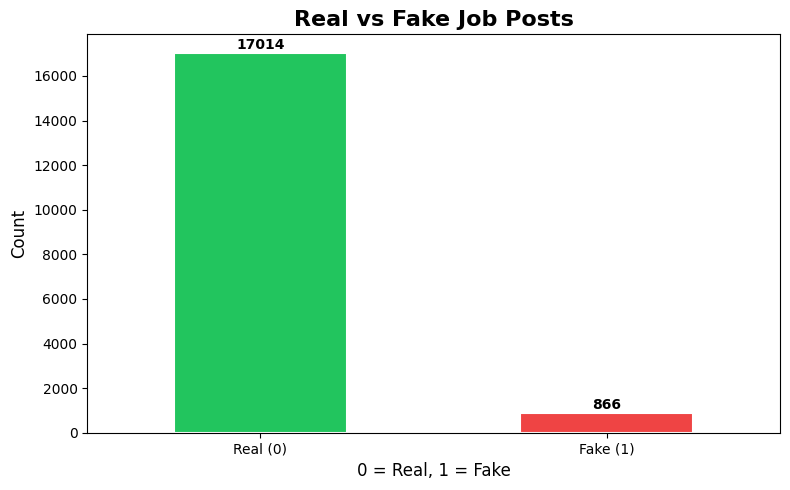

In [3]:
# 3. Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#22c55e', '#ef4444']
df['fraudulent'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='white', linewidth=1.5)
ax.set_title('Real vs Fake Job Posts', fontsize=16, fontweight='bold')
ax.set_xlabel('0 = Real, 1 = Fake', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['Real (0)', 'Fake (1)'], rotation=0)
for i, v in enumerate(df['fraudulent'].value_counts().values):
    ax.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/class_distribution.png', dpi=150)
plt.show()

In [4]:
# 4. Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                     Missing Count  Missing %
salary_range                 15012      83.96
department                   11547      64.58
required_education            8105      45.33
benefits                      7212      40.34
required_experience           7050      39.43
function                      6455      36.10
industry                      4903      27.42
employment_type               3471      19.41
company_profile               3308      18.50
requirements                  2696      15.08
location                       346       1.94
description                      1       0.01


In [5]:
# 5. Fake job patterns — what sectors?
fake_jobs = df[df['fraudulent'] == 1]
print('Top industries in fake jobs:')
print(fake_jobs['industry'].value_counts().head(10))
print()
print('Top employment types in fake jobs:')
print(fake_jobs['employment_type'].value_counts().head(10))

Top industries in fake jobs:
industry
Oil & Energy                           109
Accounting                              57
Hospital & Health Care                  51
Marketing and Advertising               45
Financial Services                      35
Information Technology and Services     32
Telecommunications                      26
Real Estate                             24
Consumer Services                       24
Leisure, Travel & Tourism               21
Name: count, dtype: int64

Top employment types in fake jobs:
employment_type
Full-time    490
Part-time     74
Contract      44
Other         15
Temporary      2
Name: count, dtype: int64


In [6]:
# 6. Correlation — has_company_logo vs fraudulent
print('Company Logo vs Fraudulent:')
print(pd.crosstab(df['has_company_logo'], df['fraudulent']))
print()
# Result: Jobs WITHOUT logo are much more likely fake
print('Has Questions vs Fraudulent:')
print(pd.crosstab(df['has_questions'], df['fraudulent']))

Company Logo vs Fraudulent:
fraudulent            0    1
has_company_logo            
0                  3077  583
1                 13937  283

Has Questions vs Fraudulent:
fraudulent        0    1
has_questions           
0              8472  616
1              8542  250


In [7]:
# 7. Word frequency analysis — what words appear in fake posts?
from collections import Counter
import re

fake_text = ' '.join(df[df['fraudulent']==1]['description'].dropna())
real_text = ' '.join(df[df['fraudulent']==0]['description'].dropna())

fake_words = Counter(fake_text.lower().split()).most_common(20)
print('Most common words in FAKE posts:', fake_words)
print()
real_words = Counter(real_text.lower().split()).most_common(20)
print('Most common words in REAL posts:', real_words)

Most common words in FAKE posts: [('and', 7906), ('to', 4315), ('the', 4179), ('of', 2752), ('a', 2320), ('in', 2190), ('for', 2102), ('with', 1751), ('are', 1188), ('is', 1151), ('work', 910), ('you', 880), ('we', 876), ('on', 859), ('as', 765), ('be', 700), ('or', 693), ('our', 688), ('will', 617), ('that', 616)]

Most common words in REAL posts: [('and', 167095), ('the', 93914), ('to', 92320), ('of', 64767), ('a', 60547), ('in', 51161), ('for', 44287), ('with', 39351), ('our', 30090), ('is', 27651), ('you', 22470), ('are', 21995), ('will', 21886), ('be', 20782), ('we', 19425), ('as', 19100), ('on', 17760), ('an', 14255), ('that', 13847), ('team', 13035)]
